# GBM
에이다부스트와 유사하지만 가중치 업데이트를 경사하강법을 이용하는 것이 큰 차이

In [4]:
import os
import pandas as pd
from sklearn.metrics import accuracy_score

def get_new_feature_name_df(old_feature_name_df):
    feature_dup_df = pd.DataFrame(data=old_feature_name_df.groupby('column_name').cumcount(),
                                  columns=['dup_cnt'])
    feature_dup_df = feature_dup_df.reset_index()
    new_feature_name_df = pd.merge(old_feature_name_df.reset_index(), feature_dup_df, how='outer')
    new_feature_name_df['column_name'] = new_feature_name_df[['column_name', 'dup_cnt']].apply(lambda x : x[0]+'_'+str(x[1])
                                                                                         if x[1] >0 else x[0] ,  axis=1)
    new_feature_name_df = new_feature_name_df.drop(['index'], axis=1)
    return new_feature_name_df


In [7]:
def get_human_dataset():
    feature_name_df = pd.read_csv('human_activity/features.txt',sep='\s+',
                        header=None,names=['column_index','column_name'])
    new_feature_name_df = get_new_feature_name_df(feature_name_df)
    feature_name = new_feature_name_df.iloc[:, 1].values.tolist()
    X_train = pd.read_csv('human_activity/train/X_train.txt',sep='\s+', names=feature_name)
    X_test = pd.read_csv('human_activity/test/X_test.txt',sep='\s+', names=feature_name)
    y_train = pd.read_csv('human_activity/train/y_train.txt',sep='\s+',header=None,names=['action'])
    y_test = pd.read_csv('human_activity/test/y_test.txt',sep='\s+',header=None,names=['action'])
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = get_human_dataset()

In [8]:
from sklearn.ensemble import GradientBoostingClassifier
import time
import warnings
warnings.filterwarnings('ignore')

X_train, X_test, y_train, y_test = get_human_dataset()

start_time = time.time()

gb_clf = GradientBoostingClassifier(random_state=0)
gb_clf.fit(X_train, y_train)
gb_pred = gb_clf.predict(X_test)
gb_accuracy = accuracy_score(y_test, gb_pred)

print("GBM 정확도 : {0:.4f}".format(gb_accuracy))
print("GBM 수행 시간 : {0:.1f}초".format(time.time() - start_time))

GBM 정확도 : 0.9389
GBM 수행 시간 : 1592.2초


# XGBosst
GBM에 기반, GBM의 느린 수행 시간과 과적합 규제 부재 등의 문제 해결

In [10]:
%pip install xgboost --upgrade

Defaulting to user installation because normal site-packages is not writeable
     -------------------------------------- 101.7/101.7 MB 1.2 MB/s eta 0:00:00
Defaulting to user installation because normal site-packages is not writeable
     -------------------------------------- 101.7/101.7 MB 2.4 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [13]:
import xgboost as xgb
from xgboost import XGBClassifier

위스콘신 유방암 예측

In [14]:
import xgboost as xgb
from xgboost import plot_importance
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

dataset = load_breast_cancer()
features = dataset.data
labels = dataset.target
cancer_df = pd.DataFrame(data = features, columns = dataset.feature_names)
cancer_df["target"] = labels
cancer_df.head(3)
     

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0


In [15]:
print(dataset.target_names)
print(cancer_df["target"].value_counts())

['malignant' 'benign']
1    357
0    212
Name: target, dtype: int64


In [16]:
x_features = cancer_df.iloc[:, :-1]
y_label = cancer_df.iloc[:, -1]

x_train, x_test, y_train, y_test = train_test_split(x_features, y_label, test_size = 0.2, random_state = 156)

x_tr, x_val, y_tr, y_val = train_test_split(x_train, y_train, test_size = 0.1, random_state = 156)

print(x_train.shape, x_test.shape)
print(x_tr.shape, x_val.shape)

(455, 30) (114, 30)
(409, 30) (46, 30)


In [17]:
dtr = xgb.DMatrix(data=x_tr, label=y_tr)
dval = xgb.DMatrix(data=x_val, label=y_val)
dtest = xgb.DMatrix(data=x_test , label=y_test)

In [18]:
params = {"max_depth" : 3,
          "eta" : 0.05,
          "objective" : "binary:logistic",
          "eval_metric" : "logloss"
          }
num_rounds = 400

In [19]:
eval_list = [(dtr, "train"), (dval, "eval")]

xgb_model = xgb.train(params = params, dtrain = dtr, num_boost_round = num_rounds, early_stopping_rounds = 50, evals = eval_list)

[0]	train-logloss:0.62473	eval-logloss:0.63088
[1]	train-logloss:0.58662	eval-logloss:0.60461
[2]	train-logloss:0.55210	eval-logloss:0.58205
[3]	train-logloss:0.52068	eval-logloss:0.56165
[4]	train-logloss:0.49173	eval-logloss:0.54101
[5]	train-logloss:0.46517	eval-logloss:0.52206
[6]	train-logloss:0.44009	eval-logloss:0.50271
[7]	train-logloss:0.41646	eval-logloss:0.48606
[8]	train-logloss:0.39505	eval-logloss:0.46961
[9]	train-logloss:0.37523	eval-logloss:0.45485
[10]	train-logloss:0.35682	eval-logloss:0.44120
[11]	train-logloss:0.33964	eval-logloss:0.43123
[12]	train-logloss:0.32279	eval-logloss:0.41962
[13]	train-logloss:0.30783	eval-logloss:0.40848
[14]	train-logloss:0.29308	eval-logloss:0.39857
[15]	train-logloss:0.27928	eval-logloss:0.38945
[16]	train-logloss:0.26681	eval-logloss:0.38171
[17]	train-logloss:0.25498	eval-logloss:0.37381
[18]	train-logloss:0.24352	eval-logloss:0.36656
[19]	train-logloss:0.23307	eval-logloss:0.36014
[20]	train-logloss:0.22290	eval-logloss:0.35395
[2

In [20]:
pred_probs = xgb_model.predict(dtest)
print("predict() 수행 결과값을 10개만 표시, 예측 확률 값으로 표시됨")
print(np.round(pred_probs[:10], 3))

preds = [1 if x > 0.5 else 0 for x in pred_probs]
print("예측값 10개만 표시 :", preds[:10])

predict() 수행 결과값을 10개만 표시, 예측 확률 값으로 표시됨
[0.938 0.004 0.776 0.058 0.975 1.    0.999 0.999 0.998 0.   ]
예측값 10개만 표시 : [1, 0, 1, 0, 1, 1, 1, 1, 1, 0]


In [21]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, f1_score, roc_auc_score

def get_clf_eval(y_test, pred, pred_proba):
    confusion = confusion_matrix(y_test, pred)
    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    roc_auc = roc_auc_score(y_test, pred_proba)

    print("오차 행렬")
    print(confusion)
    print("정확도: {0:.4f}, 정밀도: {1:.4f}, 재현율: {2:.4f}, F1: {3:.4f}, AUC: {4:.4f}".format(
        accuracy, precision, recall, f1, roc_auc
    ))

In [22]:
get_clf_eval(y_test, preds, pred_probs)

오차 행렬
[[35  2]
 [ 2 75]]
정확도: 0.9649, 정밀도: 0.9740, 재현율: 0.9740, F1: 0.9740, AUC: 0.9965


<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

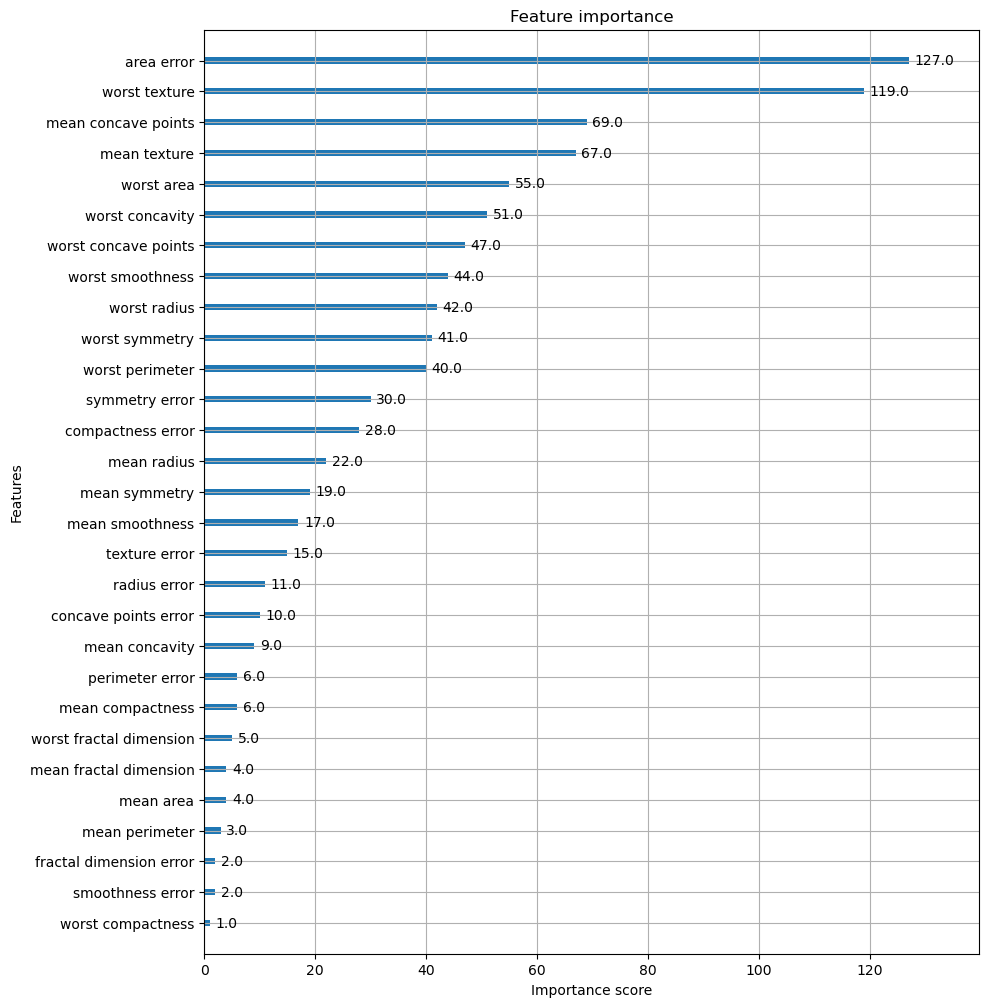

In [23]:
# xgboost 패키지에 내장된 시각화 기능 수행
import matplotlib.pyplot as plt
%matplotlib inline

fig, ax = plt.subplots(figsize = (10, 12))
plot_importance(xgb_model, ax = ax)

# 사이킷런 래퍼 XGBoost의 개요 및 적용

In [24]:
from xgboost import XGBClassifier

xgb_wrapper = XGBClassifier(n_estimators = 400, learning_rate = 0.05, max_depth = 3)
xgb_wrapper.fit(x_train, y_train, verbose = True)
w_preds = xgb_wrapper.predict(x_test)
w_pred_proba = xgb_wrapper.predict_proba(x_test)[:, 1]

In [25]:
get_clf_eval(y_test, w_preds, w_pred_proba)

오차 행렬
[[34  3]
 [ 1 76]]
정확도: 0.9649, 정밀도: 0.9620, 재현율: 0.9870, F1: 0.9744, AUC: 0.9951


In [26]:
from xgboost import XGBClassifier
import numpy as np

# 데이터 변환
x_tr_np = np.asarray(x_tr, dtype=np.float32)
x_val_np = np.asarray(x_val, dtype=np.float32)
x_test_np = np.asarray(x_test, dtype=np.float32)

y_tr_np = np.asarray(y_tr).reshape(-1)
y_val_np = np.asarray(y_val).reshape(-1)
y_test_np = np.asarray(y_test).reshape(-1)

xgb_wrapper = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=3,
    early_stopping_rounds=50,
    eval_metric="logloss",
    random_state=156
)

evals = [(x_tr_np, y_tr_np), (x_val_np, y_val_np)]

xgb_wrapper.fit(
    x_tr_np,
    y_tr_np,
    eval_set=evals,
    verbose=True
)

ws50_preds = xgb_wrapper.predict(x_test_np)
ws50_pred_proba = xgb_wrapper.predict_proba(x_test_np)[:, 1]

[0]	validation_0-logloss:0.62473	validation_1-logloss:0.63088
[1]	validation_0-logloss:0.58662	validation_1-logloss:0.60461
[2]	validation_0-logloss:0.55210	validation_1-logloss:0.58205
[3]	validation_0-logloss:0.52068	validation_1-logloss:0.56165
[4]	validation_0-logloss:0.49173	validation_1-logloss:0.54101
[5]	validation_0-logloss:0.46517	validation_1-logloss:0.52206
[6]	validation_0-logloss:0.44009	validation_1-logloss:0.50271
[7]	validation_0-logloss:0.41646	validation_1-logloss:0.48606
[8]	validation_0-logloss:0.39505	validation_1-logloss:0.46961
[9]	validation_0-logloss:0.37523	validation_1-logloss:0.45485
[10]	validation_0-logloss:0.35682	validation_1-logloss:0.44120
[11]	validation_0-logloss:0.33964	validation_1-logloss:0.43123
[12]	validation_0-logloss:0.32279	validation_1-logloss:0.41962
[13]	validation_0-logloss:0.30783	validation_1-logloss:0.40848
[14]	validation_0-logloss:0.29308	validation_1-logloss:0.39857
[15]	validation_0-logloss:0.27928	validation_1-logloss:0.38945
[1

In [27]:
get_clf_eval(y_test, ws50_preds, ws50_pred_proba)

오차 행렬
[[35  2]
 [ 2 75]]
정확도: 0.9649, 정밀도: 0.9740, 재현율: 0.9740, F1: 0.9740, AUC: 0.9965


In [28]:
from xgboost import XGBClassifier
import numpy as np

x_tr_np = np.asarray(x_tr, dtype=np.float32)
x_val_np = np.asarray(x_val, dtype=np.float32)
x_test_np = np.asarray(x_test, dtype=np.float32)

y_tr_np = np.asarray(y_tr).reshape(-1)
y_val_np = np.asarray(y_val).reshape(-1)
y_test_np = np.asarray(y_test).reshape(-1)

xgb_wrapper10 = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=3,
    early_stopping_rounds=10,
    eval_metric="logloss",
    random_state=156
)

evals = [(x_tr_np, y_tr_np), (x_val_np, y_val_np)]

# 학습
xgb_wrapper10.fit(
    x_tr_np,
    y_tr_np,
    eval_set=evals,
    verbose=True
)

# 예측
ws10_preds = xgb_wrapper10.predict(x_test_np)
ws10_pred_proba = xgb_wrapper10.predict_proba(x_test_np)[:, 1]

# 평가
get_clf_eval(y_test_np, ws10_preds, ws10_pred_proba)

[0]	validation_0-logloss:0.62473	validation_1-logloss:0.63088
[1]	validation_0-logloss:0.58662	validation_1-logloss:0.60461
[2]	validation_0-logloss:0.55210	validation_1-logloss:0.58205
[3]	validation_0-logloss:0.52068	validation_1-logloss:0.56165
[4]	validation_0-logloss:0.49173	validation_1-logloss:0.54101
[5]	validation_0-logloss:0.46517	validation_1-logloss:0.52206
[6]	validation_0-logloss:0.44009	validation_1-logloss:0.50271
[7]	validation_0-logloss:0.41646	validation_1-logloss:0.48606
[8]	validation_0-logloss:0.39505	validation_1-logloss:0.46961
[9]	validation_0-logloss:0.37523	validation_1-logloss:0.45485
[10]	validation_0-logloss:0.35682	validation_1-logloss:0.44120
[11]	validation_0-logloss:0.33964	validation_1-logloss:0.43123
[12]	validation_0-logloss:0.32279	validation_1-logloss:0.41962
[13]	validation_0-logloss:0.30783	validation_1-logloss:0.40848
[14]	validation_0-logloss:0.29308	validation_1-logloss:0.39857
[15]	validation_0-logloss:0.27928	validation_1-logloss:0.38945
[1

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

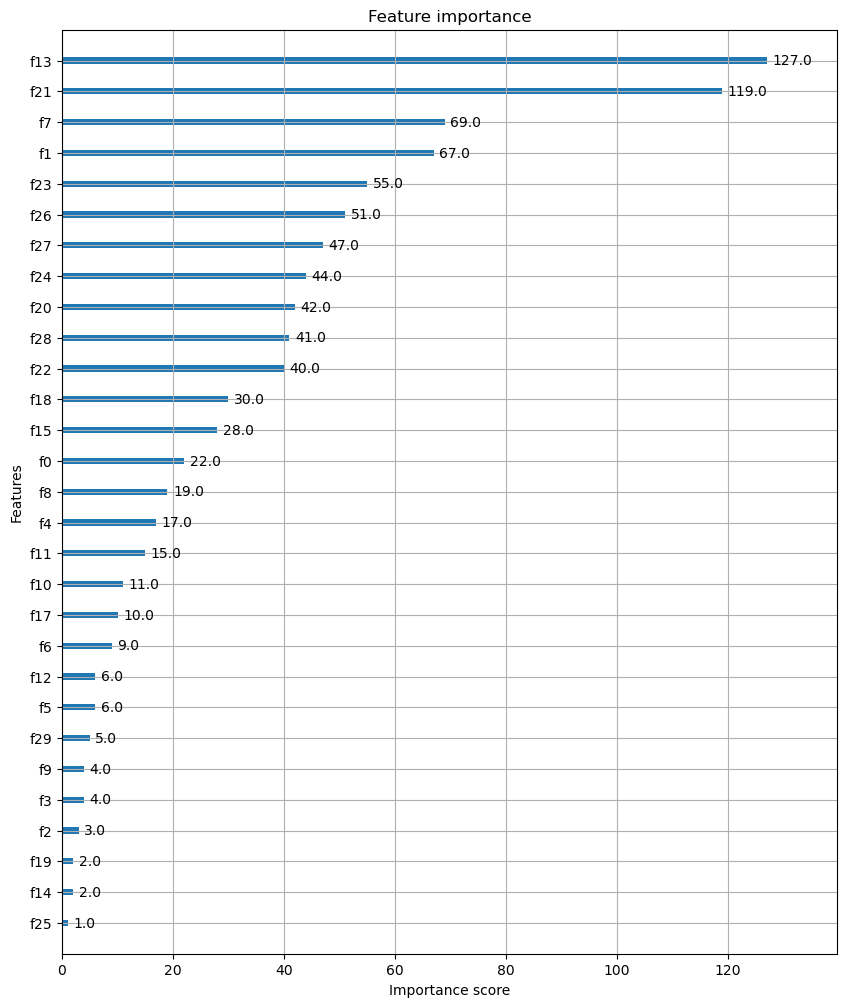

In [29]:
from xgboost import plot_importance
import matplotlib.pyplot as plt
%matplotlib inline

fig, ax = plt.subplots(figsize = (10, 12))
plot_importance(xgb_wrapper, ax = ax)

# LightGBM

In [30]:
%pip install lightgbm==3.3.2

Defaulting to user installation because normal site-packages is not writeable
     ---------------------------------------- 1.0/1.0 MB 860.2 kB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [31]:
import lightgbm
from lightgbm import LGBMClassifier

# 위스콘신 유방암 예측

In [32]:
from lightgbm import LGBMClassifier

import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

dataset = load_breast_cancer()

cancer_df = pd.DataFrame(data = dataset.data, columns = dataset.feature_names)
cancer_df["target"] = dataset.target
x_features = cancer_df.iloc[:, :-1]
y_label = cancer_df.iloc[:, -1]

x_train, x_test, y_train, y_test = train_test_split(x_features, y_label, test_size = 0.2, random_state = 156)

x_tr, x_val, y_tr, y_val = train_test_split(x_train, y_train, test_size = 0.1, random_state = 156)

lgbm_wrapper = LGBMClassifier(n_estimators = 400, learning_rate = 0.05)

evals = [(x_tr, y_tr), (x_val, y_val)]
lgbm_wrapper.fit(x_tr, y_tr, early_stopping_rounds = 50, eval_metric = "logloss", eval_set = evals, verbose = True)
preds = lgbm_wrapper.predict(x_test)
pred_proba = lgbm_wrapper.predict_proba(x_test)[:, 1]

[1]	training's binary_logloss: 0.625671	valid_1's binary_logloss: 0.628248
[2]	training's binary_logloss: 0.588173	valid_1's binary_logloss: 0.601106
[3]	training's binary_logloss: 0.554518	valid_1's binary_logloss: 0.577587
[4]	training's binary_logloss: 0.523972	valid_1's binary_logloss: 0.556324
[5]	training's binary_logloss: 0.49615	valid_1's binary_logloss: 0.537407
[6]	training's binary_logloss: 0.470108	valid_1's binary_logloss: 0.519401
[7]	training's binary_logloss: 0.446647	valid_1's binary_logloss: 0.502637
[8]	training's binary_logloss: 0.425055	valid_1's binary_logloss: 0.488311
[9]	training's binary_logloss: 0.405125	valid_1's binary_logloss: 0.474664
[10]	training's binary_logloss: 0.386526	valid_1's binary_logloss: 0.461267
[11]	training's binary_logloss: 0.367027	valid_1's binary_logloss: 0.444274
[12]	training's binary_logloss: 0.350713	valid_1's binary_logloss: 0.432755
[13]	training's binary_logloss: 0.334601	valid_1's binary_logloss: 0.421371
[14]	training's binary

In [33]:
get_clf_eval(y_test, preds, pred_proba)

오차 행렬
[[34  3]
 [ 2 75]]
정확도: 0.9561, 정밀도: 0.9615, 재현율: 0.9740, F1: 0.9677, AUC: 0.9877


<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

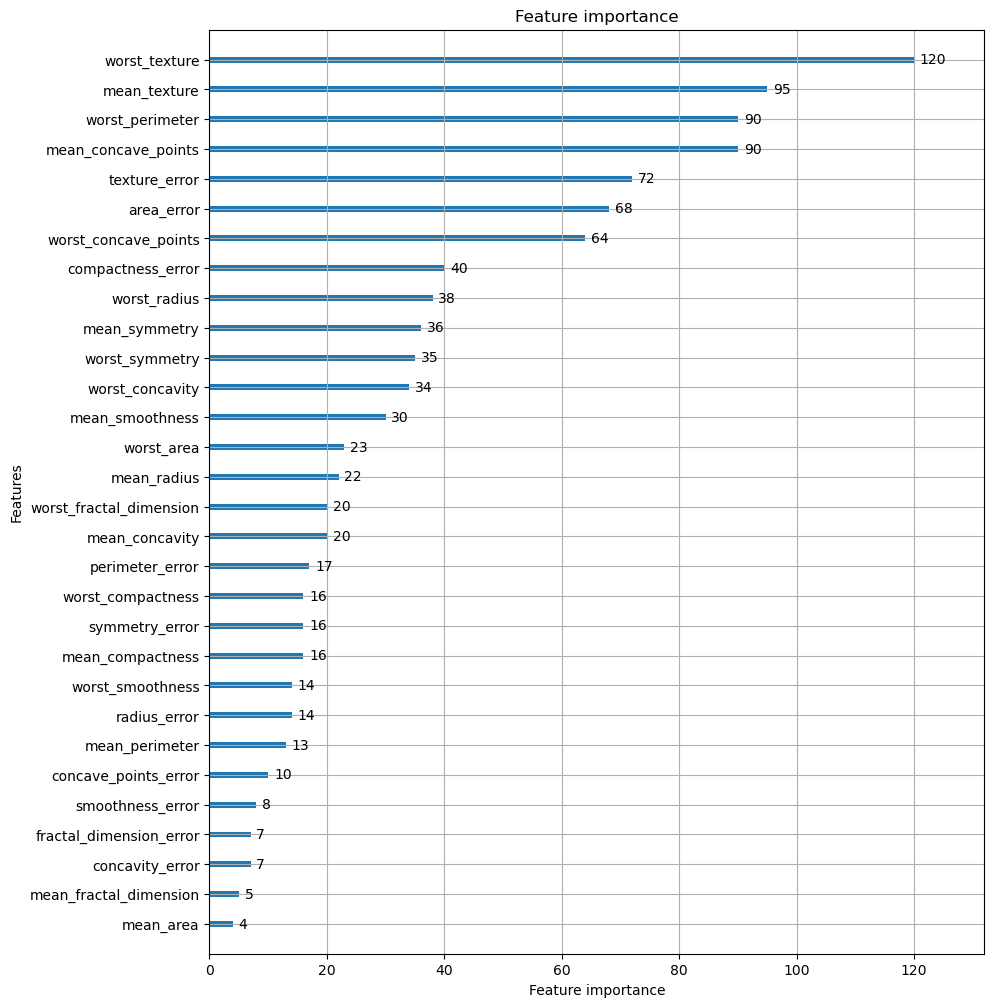

In [34]:
from lightgbm import plot_importance
import matplotlib.pyplot as plt
%matplotlib inline

fig, ax = plt.subplots(figsize = (10, 12))
plot_importance(lgbm_wrapper, ax = ax)

# 베이지안 최적화 기반의 HyperOpt를 이용한 하이퍼 파라미터 튜닝

In [35]:
params = {
    "max_depth": [10, 20, 30, 40, 50],
    "num_leaves": [35, 45, 55, 65],
    "colsample_bytree": [0.5, 0.6, 0.7, 0.8, 0.9],
    "subsample": [0.5, 0.6, 0.7, 0.8, 0.9],
    "min_child_weight": [10, 20, 30, 40],
    "reg_alpha": [0.01, 0.05, 0.1]
}

In [36]:
%pip install hyperopt

Defaulting to user installation because normal site-packages is not writeable
     ---------------------------------------- 1.6/1.6 MB 1.1 MB/s eta 0:00:00
     -------------------------------------- 203.0/203.0 kB 1.5 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [37]:
from hyperopt import hp

search_space = {"x" : hp.quniform("x", -10, 10, 1), "y" : hp.quniform("y", -15, 15, 1)}

In [38]:
from hyperopt import STATUS_OK

def objective_func(search_space):
    x = search_space["x"]
    y = search_space["y"]
    retval = x**2 - 20*y

    return retval

In [39]:
from hyperopt import fmin, tpe, Trials
trial_val = Trials()

best_01 = fmin(fn = objective_func, space = search_space, algo = tpe.suggest, max_evals = 5, trials = trial_val, rstate = np.random.default_rng(seed = 0))
print("best :", best_01)

100%|██████████| 5/5 [00:00<00:00, 384.78trial/s, best loss: -224.0]
best : {'x': -4.0, 'y': 12.0}


In [40]:
trial_val = Trials()

best_02 = fmin(fn = objective_func, space = search_space, algo = tpe.suggest, max_evals = 20, trials = trial_val, rstate = np.random.default_rng(seed = 0))
print("best :", best_02)

100%|██████████| 20/20 [00:00<00:00, 456.31trial/s, best loss: -296.0]
best : {'x': 2.0, 'y': 15.0}


In [41]:
print(trial_val.results)

[{'loss': -64.0, 'status': 'ok'}, {'loss': -184.0, 'status': 'ok'}, {'loss': 56.0, 'status': 'ok'}, {'loss': -224.0, 'status': 'ok'}, {'loss': 61.0, 'status': 'ok'}, {'loss': -296.0, 'status': 'ok'}, {'loss': -40.0, 'status': 'ok'}, {'loss': 281.0, 'status': 'ok'}, {'loss': 64.0, 'status': 'ok'}, {'loss': 100.0, 'status': 'ok'}, {'loss': 60.0, 'status': 'ok'}, {'loss': -39.0, 'status': 'ok'}, {'loss': 1.0, 'status': 'ok'}, {'loss': -164.0, 'status': 'ok'}, {'loss': 21.0, 'status': 'ok'}, {'loss': -56.0, 'status': 'ok'}, {'loss': 284.0, 'status': 'ok'}, {'loss': 176.0, 'status': 'ok'}, {'loss': -171.0, 'status': 'ok'}, {'loss': 0.0, 'status': 'ok'}]


In [42]:
print(trial_val.vals)

{'x': [-6.0, -4.0, 4.0, -4.0, 9.0, 2.0, 10.0, -9.0, -8.0, -0.0, -0.0, 1.0, 9.0, 6.0, 9.0, 2.0, -2.0, -4.0, 7.0, -0.0], 'y': [5.0, 10.0, -2.0, 12.0, 1.0, 15.0, 7.0, -10.0, 0.0, -5.0, -3.0, 2.0, 4.0, 10.0, 3.0, 3.0, -14.0, -8.0, 11.0, -0.0]}


In [43]:
import pandas as pd

losses = [loss_dict['loss'] for loss_dict in trial_val.results]

result_df = pd.DataFrame({'x': trial_val.vals['x'], 'y': trial_val.vals['y'], 'losses': losses})
result_df

,x,y,losses
0,-6.0,5.0,-64.0
1,-4.0,10.0,-184.0
2,4.0,-2.0,56.0
3,-4.0,12.0,-224.0
4,9.0,1.0,61.0
5,2.0,15.0,-296.0
6,10.0,7.0,-40.0
7,-9.0,-10.0,281.0
8,-8.0,0.0,64.0
9,-0.0,-5.0,100.0


HyperOpt를 이용한 XGBoost 하이퍼 파라미터 최적화

In [44]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

dataset = load_breast_cancer()

cancer_df = pd.DataFrame(data=dataset.data, columns=dataset.feature_names)
cancer_df['target']= dataset.target
X_features = cancer_df.iloc[:, :-1]
y_label = cancer_df.iloc[:, -1]

In [45]:
X_train, X_test, y_train, y_test=train_test_split(X_features, y_label, test_size=0.2, random_state=156 )

X_tr, X_val, y_tr, y_val= train_test_split(X_train, y_train, test_size=0.1, random_state=156 )

In [46]:
from hyperopt import hp

xgb_search_space = {'max_depth': hp.quniform('max_depth', 5, 20, 1),
                    'min_child_weight': hp.quniform('min_child_weight', 1, 2, 1),
                    'learning_rate': hp.uniform('learning_rate', 0.01, 0.2),
                    'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 1),
                   }

In [48]:
from sklearn.model_selection import cross_val_score
from xgboost import XGBClassifier
from hyperopt import STATUS_OK

def objective_func(search_space):
    xgb_clf = XGBClassifier(n_estimators=100, max_depth=int(search_space['max_depth']),
                            min_child_weight=int(search_space['min_child_weight']),
                            learning_rate=search_space['learning_rate'],
                            colsample_bytree=search_space['colsample_bytree'],
                            eval_metric='logloss')
    accuracy = cross_val_score(xgb_clf, X_train, y_train, scoring='accuracy', cv=3)

    return {'loss':-1 * np.mean(accuracy), 'status': STATUS_OK}

In [49]:
from hyperopt import fmin, tpe, Trials

trial_val = Trials()
best = fmin(fn=objective_func,
            space=xgb_search_space,
            algo=tpe.suggest,
            max_evals=50,
            trials=trial_val, rstate=np.random.default_rng(seed=9))
print('best:', best)

100%|██████████| 50/50 [00:22<00:00,  2.20trial/s, best loss: -0.9692401533635412]
best: {'colsample_bytree': 0.7816916965882073, 'learning_rate': 0.15978354626451718, 'max_depth': 20.0, 'min_child_weight': 2.0}


In [50]:
print('colsample_bytree:{0}, learning_rate:{1}, max_depth:{2}, min_child_weight:{3}'.format(
    round(best['colsample_bytree'], 5), round(best['learning_rate'], 5),
    int(best['max_depth']), int(best['min_child_weight'])))

colsample_bytree:0.78169, learning_rate:0.15978, max_depth:20, min_child_weight:2


In [51]:
xgb_wrapper = XGBClassifier(
    n_estimators=400,
    learning_rate=round(best['learning_rate'], 5),
    max_depth=int(best['max_depth']),
    min_child_weight=int(best['min_child_weight']),
    colsample_bytree=round(best['colsample_bytree'], 5),
    early_stopping_rounds=50,
    eval_metric='logloss'
)

evals = [(X_tr, y_tr), (X_val, y_val)]

xgb_wrapper.fit(
    X_tr,
    y_tr,
    eval_set=evals,
    verbose=True
)

preds = xgb_wrapper.predict(X_test)
pred_proba = xgb_wrapper.predict_proba(X_test)[:, 1]

[0]	validation_0-logloss:0.54379	validation_1-logloss:0.58107
[1]	validation_0-logloss:0.45190	validation_1-logloss:0.51622
[2]	validation_0-logloss:0.38041	validation_1-logloss:0.45865
[3]	validation_0-logloss:0.32496	validation_1-logloss:0.41740
[4]	validation_0-logloss:0.28110	validation_1-logloss:0.38619
[5]	validation_0-logloss:0.24305	validation_1-logloss:0.35807
[6]	validation_0-logloss:0.21292	validation_1-logloss:0.34329
[7]	validation_0-logloss:0.18874	validation_1-logloss:0.32475
[8]	validation_0-logloss:0.16768	validation_1-logloss:0.31701
[9]	validation_0-logloss:0.14904	validation_1-logloss:0.30362
[10]	validation_0-logloss:0.13466	validation_1-logloss:0.29923
[11]	validation_0-logloss:0.12170	validation_1-logloss:0.29388
[12]	validation_0-logloss:0.11059	validation_1-logloss:0.28602
[13]	validation_0-logloss:0.09966	validation_1-logloss:0.27923
[14]	validation_0-logloss:0.09056	validation_1-logloss:0.27397
[15]	validation_0-logloss:0.08342	validation_1-logloss:0.27112
[1

In [52]:
get_clf_eval(y_test, preds, pred_proba)

오차 행렬
[[34  3]
 [ 3 74]]
정확도: 0.9474, 정밀도: 0.9610, 재현율: 0.9610, F1: 0.9610, AUC: 0.9919
